<a href="https://colab.research.google.com/github/aleedacharly/30-Days-of-GIS/blob/main/Terraclimate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ── CELL 1: IMPORTS ───────────────────────────────────────────────────────────
#
# Four libraries do the heavy lifting:
#   xarray     — reads NetCDF files (the standard format for gridded climate data)
#   rioxarray  — adds spatial clipping and CRS support to xarray DataArrays
#   geopandas  — loads country/continent boundaries as vector polygons
#   scipy      — provides the Gaussian filter for smoothing
#
# Run this once to install if needed:
!pip install xarray rioxarray geopandas matplotlib numpy netCDF4 scipy

import numpy as np
import xarray as xr
import rioxarray
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter

print("All imports OK")

All imports OK


In [4]:
# ── CELL 2: CONFIG ────────────────────────────────────────────────────────────
#
# Everything you might want to change lives here.
# Swap REGION, tweak the break percentiles, adjust smoothing —
# then re-run from Cell 3 downward. No need to touch any other cell.

# Data files — download from https://www.climatologylab.org/terraclimate.html
# Pick a year, select variables tmax and ppt, download as NetCDF
TMAX_FILE = "TerraClimate_tmax_2025.nc"
PPT_FILE  = "TerraClimate_ppt_2025.nc"
BORDERS   = "ne_10m_admin_0_countries.zip"  # Natural Earth 1:10m countries

# ── REGION ───────────────────────────────────────────────────────────────────
# Three ways to define a region — uncomment the one you want:

REGION = "Asia"          # a continent name
# REGION = [”Germany”, “France”]   # a list of country names
# REGION = “World”                  # the whole world

# ── COLOR & SMOOTHING ─────────────────────────────────────────────────────────
N     = 4     # palette grid size — 4×4 = 16 colors, matches the reference
SIGMA = 2.0   # Gaussian smoothing strength — higher = smoother blobs

# ── QUANTILE BREAK PERCENTILES ────────────────────────────────────────────────
# These control the orange/blue balance.
# Equal bins would be [0, 25, 50, 75, 100] — each bin gets 25% of pixels.
# We skew them so more pixels fall into warm/dry bins → more orange, less teal.
#
# Temp: top 30% of pixels are ‘hot’ (above the 70th percentile)
# Ppt:  top 10% of pixels are ‘very wet’ (above the 90th percentile)
TEMP_BREAKS = [0, 20, 45, 70, 100]
PPT_BREAKS  = [0, 60, 78, 90, 100]

# ── PALETTE ───────────────────────────────────────────────────────────────────
# 4×4 color matrix — hex codes sampled directly from the reference image.
# Layout:
#   row 0 = high precipitation (top of legend)    → teal / blue-green
#   row 3 = low  precipitation (bottom of legend) → grey / peach / orange
#   col 0 = low  temperature   (left of legend)   → cool tones
#   col 3 = high temperature   (right of legend)  → warm tones
PALETTE = [
    ["#3a9dbf", "#2a7d82", "#1e6050", "#164427"],  # high precip
    ["#7ab5c8", "#6d9490", "#5e7a62", "#4a5a30"],
    ["#b0cdd6", "#a8b5aa", "#9e9278", "#9a6e3a"],
    ["#d8d0c8", "#dbbfa4", "#dc9e72", "#dd6a2b"],  # low precip
]

FIGSIZE = (8, 8)

In [5]:
# ── CELL 3: LOAD & CLIP ───────────────────────────────────────────────────────
#
# TerraClimate files are NetCDF — a multi-dimensional array format used throughout
# climate science. Each file contains monthly data for a full year.
#
# We compute:
#   - tmax: annual MEAN of monthly maximum temperatures (already in °C — xarray
#            applies the scale factor automatically from the file metadata)
#   - ppt:  annual SUM of monthly precipitation (mm/year)
#            We use sum rather than mean so the quantile breaks spread more
#            evenly across the precipitation range.
#
# Then we write the CRS (WGS84) so rioxarray can do spatial clipping,
# load the country boundaries, select the region, and clip both rasters to it.

tmax_da = xr.open_dataset(TMAX_FILE, engine="netcdf4")["tmax"].mean("time")
ppt_da  = xr.open_dataset(PPT_FILE,  engine="netcdf4")["ppt"].sum("time")

tmax_da = tmax_da.rio.write_crs("EPSG:4326")
ppt_da  = ppt_da.rio.write_crs("EPSG:4326")

# Select the region from Natural Earth boundaries
world = gpd.read_file(BORDERS)
if isinstance(REGION, list):
    region_gdf = world[world["ADMIN"].isin(REGION)]
    print(f"Countries: {REGION}")
elif REGION == "World":
    region_gdf = world.copy()
    print("Region: World")
else:
    region_gdf = world[world["CONTINENT"] == REGION]
    print(f"Continent: {REGION} — {len(region_gdf)} countries")

# Clip both rasters to the region boundary
tmax_clip = tmax_da.rio.clip(region_gdf.geometry, region_gdf.crs, drop=True)
ppt_clip  = ppt_da.rio.clip(region_gdf.geometry,  region_gdf.crs, drop=True)

print(f"Grid size: {tmax_clip.shape}")
print(f"Temp:   {float(tmax_clip.min()):.1f}°C → {float(tmax_clip.max()):.1f}°C")
print(f"Precip: {float(ppt_clip.min()):.0f} → {float(ppt_clip.max()):.0f} mm/yr")

Continent: Asia — 59 countries
Grid size: (1623, 2883)
Temp:   -17.8°C → 39.1°C
Precip: 0 → 8622 mm/yr


Corner check:
  cold & dry  (idx  0): (0.8470588235294118, 0.8156862745098039, 0.7843137254901961)  → should be light grey
  hot  & dry  (idx  3): (0.8666666666666667, 0.41568627450980394, 0.16862745098039217)  → should be orange
  cold & wet  (idx 12): (0.22745098039215686, 0.615686274509804, 0.7490196078431373) → should be teal/blue
  hot  & wet  (idx 15): (0.08627450980392157, 0.26666666666666666, 0.15294117647058825) → should be dark green


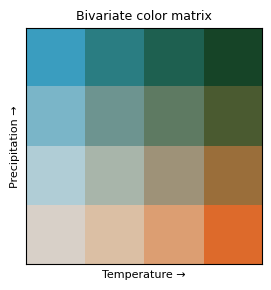

In [6]:
# ── CELL 4: BIVARIATE PALETTE ─────────────────────────────────────────────────
#
# The core idea: instead of one color ramp, we build a 2D color matrix.
# Each cell in the N×N grid represents a combination of temperature and
# precipitation quantile bins.
#
# The 16 hex codes were sampled directly from the reference image using
# pixel color picking — no color math needed, we just use the exact values.
#
# The flat_colors list maps to bi_grid indices via:
#   index = ppt_quantile * N + temp_quantile
#
# So ppt_q=0 (driest) must map to the bottom row of the palette (grey/orange),
# and ppt_q=3 (wettest) must map to the top row (teal/dark green).
# That’s why we flip the row index: palette_row = N - 1 - ppt_q

def hex_to_rgb(h):
    """Convert a hex color string to a normalised (r, g, b) tuple."""
    h = h.lstrip("#")
    return tuple(int(h[i:i+2], 16) / 255.0 for i in (0, 2, 4))

# Build the flat colormap — order must match bi_grid = ppt_q * N + temp_q
flat_colors = [hex_to_rgb(PALETTE[N - 1 - pq][tq])
               for pq in range(N)   # pq=0 → dry → PALETTE row 3
               for tq in range(N)]  # tq=0 → cold → PALETTE col 0

cmap = mcolors.ListedColormap(flat_colors)

# Build the legend grid separately — row 0 at bottom = dry, row N-1 at top = wet
legend_grid = np.array([[hex_to_rgb(PALETTE[N - 1 - row][col])
                          for col in range(N)]
                         for row in range(N)])

# Quick sanity check — verify the four corners are correct
print("Corner check:")
print(f"  cold & dry  (idx  0): {flat_colors[0]}  → should be light grey")
print(f"  hot  & dry  (idx  3): {flat_colors[3]}  → should be orange")
print(f"  cold & wet  (idx 12): {flat_colors[12]} → should be teal/blue")
print(f"  hot  & wet  (idx 15): {flat_colors[15]} → should be dark green")

# Preview the color matrix
fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(legend_grid, origin="lower", aspect="equal")
ax.set_xlabel("Temperature →", fontsize=8)
ax.set_ylabel("Precipitation →", fontsize=8)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("Bivariate color matrix", fontsize=9)
plt.tight_layout()
plt.show()

In [7]:
# ── CELL 5: CLASSIFY + SMOOTH ─────────────────────────────────────────────────
#
# Step 1 — Quantile classification
#   For each pixel we ask: which temperature bin does it fall in? (0 to N-1)
#   Then: which precipitation bin? (0 to N-1)
#   Then combine: index = ppt_bin * N + temp_bin
#   This single integer maps to one color in our palette.
#
#   We use *asymmetric* percentile breaks instead of equal-frequency bins.
#   Equal bins would put exactly 25% of pixels in each category — but that
#   makes a tropical continent like South America look too uniformly wet/warm.
#   Skewed breaks push more pixels into the dry/warm categories, so the map
#   shows more orange and reserves the deep teal for truly exceptional rainfall.
#
# Step 2 — Gaussian smoothing
#   TerraClimate has ~4km resolution which looks blocky at continent scale.
#   We smooth the raw temperature and precipitation arrays with a Gaussian
#   filter, then reclassify the smoothed values using the same breaks.

#   This blends boundaries between zones without changing the data interpretation.
temp_vals  = tmax_clip.values.flatten()
ppt_vals   = ppt_clip.values.flatten()
valid      = ~np.isnan(temp_vals) & ~np.isnan(ppt_vals)

# Compute break thresholds from the actual data distribution
t_breaks = np.nanpercentile(temp_vals[valid], TEMP_BREAKS)
p_breaks = np.nanpercentile(ppt_vals[valid],  PPT_BREAKS)

def qbin(arr, breaks):
    """Assign values to quantile bins [0, N-1]."""
    return np.clip(np.digitize(arr, breaks[1:-1]), 0, len(breaks) - 2)

# Smooth the raw rasters first, then reclassify
# (smoothing then classifying gives cleaner zone boundaries
#  than classifying then smoothing)
nan_mask = np.isnan(tmax_clip.values) | np.isnan(ppt_clip.values)

def smooth(arr):
    """Fill NaN with mean, apply Gaussian blur, return smoothed array."""
    filled = np.where(nan_mask, np.nanmean(arr), arr)
    return gaussian_filter(filled, sigma=SIGMA)

ts = smooth(tmax_clip.values).flatten()
ps = smooth(ppt_clip.values).flatten()
vm = ~nan_mask.flatten()

tq = np.full(ts.shape, -1, dtype=int)
pq = np.full(ps.shape, -1, dtype=int)
tq[vm] = qbin(ts[vm], t_breaks)
pq[vm] = qbin(ps[vm], p_breaks)

# Combined bivariate class — single integer per pixel
bi_grid = np.where(~nan_mask,
                   pq.reshape(nan_mask.shape) * N + tq.reshape(nan_mask.shape),
                   np.nan)

print(f"Grid shape: {bi_grid.shape}")
print(f"Value range: {np.nanmin(bi_grid):.0f} → {np.nanmax(bi_grid):.0f}  (expected 0–{N**2-1})")
print(f"Temp breaks:  {[f"{v:.1f}" for v in t_breaks]}")
print(f"Precip breaks: {[f"{v:.0f}" for v in p_breaks]}")

Grid shape: (1623, 2883)
Value range: 0 → 15  (expected 0–15)
Temp breaks:  ['-17.8', '11.1', '19.8', '29.6', '39.1']
Precip breaks: ['0', '503', '1220', '2052', '8622']


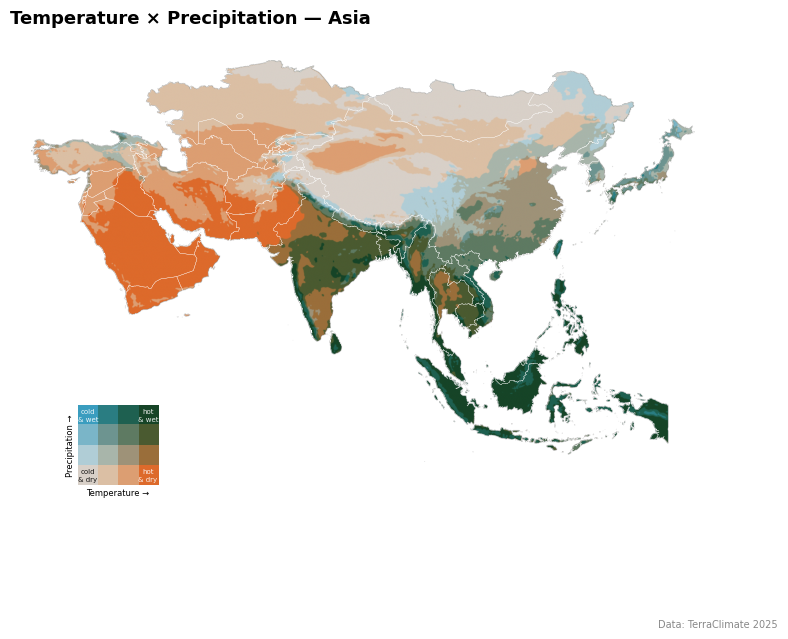

Saved: bivariate_asia.png


In [11]:
# ── CELL 6: PLOT ──────────────────────────────────────────────────────────────
#
# The map has four elements:
#   1. The bivariate raster — rendered with imshow using our custom colormap
#   2. Country/region borders — plotted on top as thin white lines
#   3. A legend inset — the 4×4 color matrix in the bottom-left corner
#   4. Corner labels on the legend — “cold & dry”, “hot & wet” etc.
#      These make the map readable without needing to explain the color system.
#
# The legend corner labels use white text on dark cells and black on the
# light grey corner (cold & dry) so they’re always readable.

def draw_legend(ax, grid_rgb, n, text_color="k", fontsize=6):
    """Draw the 2D color legend with axis labels and corner annotations."""
    ax.imshow(grid_rgb, origin="lower", aspect="equal",
              extent=[0, n, 0, n], interpolation="nearest")
    ax.set_xlabel("Temperature →", fontsize=fontsize, color=text_color, labelpad=2)
    ax.set_ylabel("Precipitation →", fontsize=fontsize, color=text_color, labelpad=2)
    ax.set_xticks([]); ax.set_yticks([])

    # Remove border — add this line inside draw_legend, replace the spine loop:
    for sp in ax.spines.values():
        sp.set_visible(False)  # instead of sp.set_edgecolor / sp.set_linewidth

    # Corner labels — black on light corner, white on dark corners
    kw = dict(fontsize=fontsize - 1, ha="center", va="center",
              alpha=0.9, linespacing=1.3, transform=ax.transData)
    ax.text(0.5,     0.5,     "cold\n& dry", color="k", **kw)
    ax.text(n - 0.5, 0.5,     "hot\n& dry",  color="w", **kw)
    ax.text(0.5,     n - 0.5, "cold\n& wet", color="w", **kw)
    ax.text(n - 0.5, n - 0.5, "hot\n& wet",  color="w", **kw)

# Compute extent and bounds for the map axes
lons   = tmax_clip.coords["lon"].values
lats   = tmax_clip.coords["lat"].values
extent = [lons.min(), lons.max(), lats.min(), lats.max()]
bounds = region_gdf.total_bounds   # [minx, miny, maxx, maxy]
pad    = max(bounds[2] - bounds[0], bounds[3] - bounds[1]) * 0.03

# Build the figure
fig = plt.figure(figsize=FIGSIZE, facecolor="white")
ax  = fig.add_axes([0.02, 0.04, 0.94, 0.88], facecolor="white")

# Bivariate raster
ax.imshow(bi_grid, cmap=cmap, vmin=0, vmax=N**2 - 1,
          extent=extent, origin="upper", aspect="auto",
          interpolation="bilinear", zorder=1)

# Country borders
region_gdf.boundary.plot(ax=ax, linewidth=0.2, color="white", zorder=2)

# Zoom to the region with a small padding buffer
ax.set_xlim(bounds[0] - pad, bounds[2] + pad)
ax.set_ylim(bounds[1] - pad, bounds[3] + pad)
ax.axis("off")

# Title
title = REGION if isinstance(REGION, str) else ", ".join(REGION)
ax.set_title(f"Temperature × Precipitation — {title}",
             color="k", fontsize=13, fontweight="bold", pad=10, loc="left")

# Legend inset — bottom-left corner of the figure
ax_leg = fig.add_axes([0.08, 0.2, 0.15, 0.1], facecolor="white")
draw_legend(ax_leg, legend_grid, N)


# Data credit
fig.text(0.98, 0.02, "Data: TerraClimate 2025",
         ha="right", va="bottom", fontsize=7, color="#888888")


fname = title.lower().replace(" ", "_").replace(",", "")
plt.savefig(f"bivariate_{fname}.png", dpi=200,
            bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved: bivariate_{fname}.png")